# Panorama Stitching from Multiple Photos — ORB + RANSAC

### Pipeline
1. Upload multiple photos (JPG / PNG)
2. Preview & reorder them left → right
3. ORB keypoint detection + FLANN-LSH matching
4. RANSAC homography between consecutive photos
5. Global canvas warp + distance-weighted blending
6. Laplacian pyramid blending
7. OpenCV stitcher comparison



In [1]:
!pip install opencv-python opencv-contrib-python numpy matplotlib --quiet


In [2]:
import cv2, numpy as np, matplotlib.pyplot as plt, os, gc
from google.colab import files

def show_image(img, title='', figsize=(16,6)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if len(img.shape)==3 else img,
               cmap=None if len(img.shape)==3 else 'gray')
    plt.title(title, fontsize=13); plt.axis('off'); plt.tight_layout(); plt.show()

def show_grid(images, titles=None, cols=4, figsize=(20,5)):
    rows = (len(images)+cols-1)//cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).flatten()
    for i, ax in enumerate(axes):
        if i < len(images):
            ax.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
            ax.set_title(titles[i] if titles else f'Photo {i}', fontsize=9)
        ax.axis('off')
    plt.tight_layout(); plt.show()

print('Imports done!')

Imports done!


## Step 3: Upload Photos
Select **all your panorama photos at once** (use Ctrl+Click or Cmd+Click).
They can be in any order — you will sort them in Step 4.

In [5]:
RESIZE_WIDTH = 640   # Resize each photo to this width. Use 480 if you hit memory issues.

print('📤 Upload your photos (JPG / PNG) — select all at once...')
uploaded = files.upload()

raw_photos = {}   # filename -> opencv image
for fname, data in uploaded.items():
    arr = np.frombuffer(data, dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    if img is None:
        print(f'  ⚠️  Could not decode {fname}, skipping.')
        continue
    if RESIZE_WIDTH:
        scale = RESIZE_WIDTH / img.shape[1]
        img = cv2.resize(img, (RESIZE_WIDTH, int(img.shape[0] * scale)))
    raw_photos[fname] = img

print(f'\n✅ Loaded {len(raw_photos)} photos:')
for i, name in enumerate(sorted(raw_photos.keys())):
    img = raw_photos[name]
    print(f'  [{i}] {name}  ({img.shape[1]}x{img.shape[0]})')

📤 Upload your photos (JPG / PNG) — select all at once...


Saving 1.jpeg to 1.jpeg
Saving 2.jpeg to 2.jpeg
Saving 3.jpeg to 3.jpeg
Saving 4.jpeg to 4.jpeg

✅ Loaded 4 photos:
  [0] 1.jpeg  (640x1422)
  [1] 2.jpeg  (640x1422)
  [2] 3.jpeg  (640x1422)
  [3] 4.jpeg  (640x1422)


## Step 4: Preview & Set Photo Order

Look at the grid below, then **edit `PHOTO_ORDER`** to list filenames from **left → right**.

Example:
```python
PHOTO_ORDER = ['img_left.jpg', 'img_mid.jpg', 'img_right.jpg']
```
Leave it as `None` to use alphabetical order (works if your files are named sequentially).

Index → Filename (alphabetical):
  [0]  1.jpeg
  [1]  2.jpeg
  [2]  3.jpeg
  [3]  4.jpeg


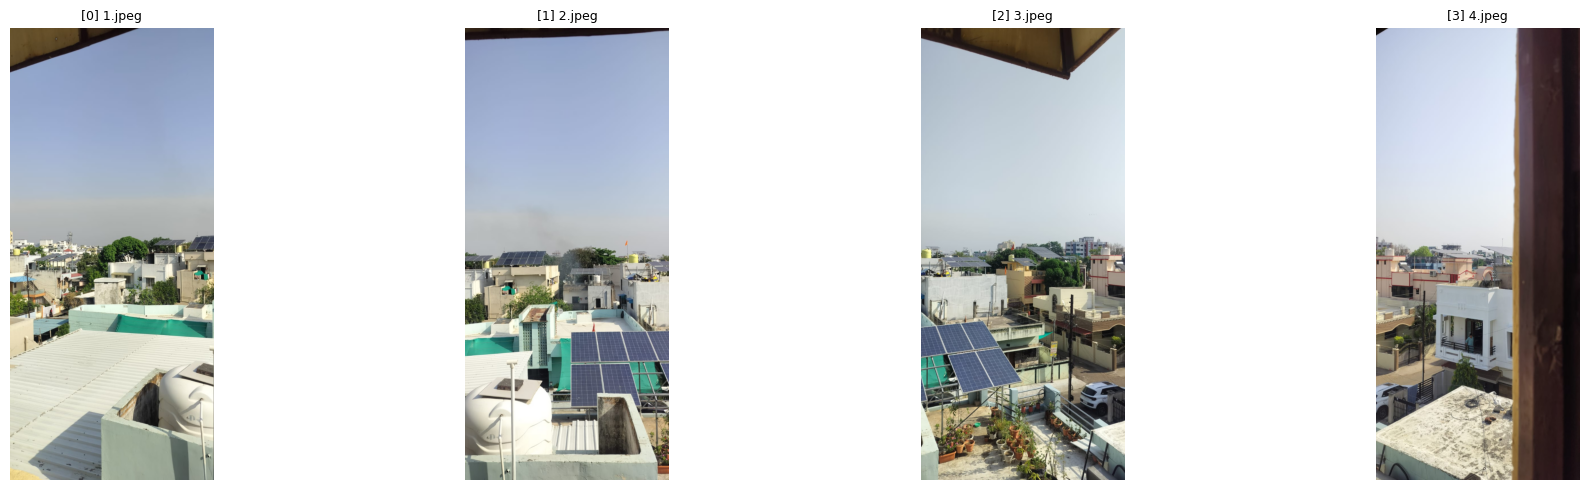

In [6]:
# ── Preview all uploaded photos ───────────────────────────────────────────────
sorted_names = sorted(raw_photos.keys())
print('Index → Filename (alphabetical):')
for i, n in enumerate(sorted_names):
    print(f'  [{i}]  {n}')

show_grid(
    [raw_photos[n] for n in sorted_names],
    titles=[f'[{i}] {n}' for i, n in enumerate(sorted_names)],
    cols=min(4, len(sorted_names)),
    figsize=(20, 5)
)

Using alphabetical order.

✅ Stitching order (4 photos):
  1. 1.jpeg
  2. 2.jpeg
  3. 3.jpeg
  4. 4.jpeg


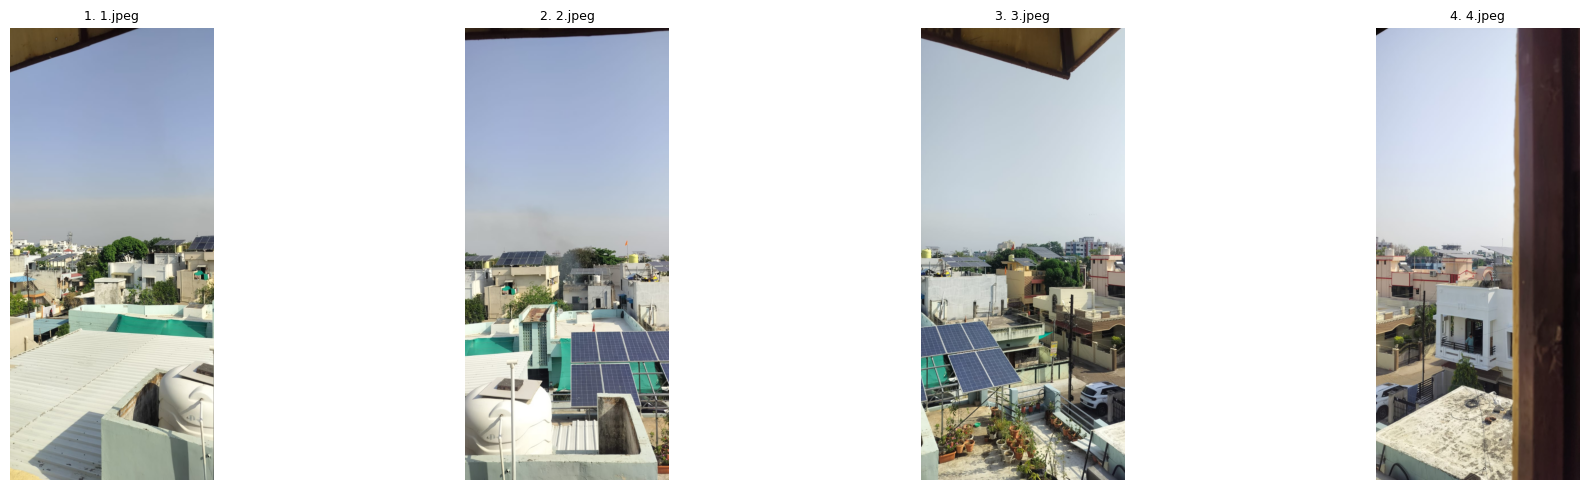

In [7]:
# ── SET YOUR ORDER HERE ───────────────────────────────────────────────────────
# Option A: list filenames explicitly (left → right)
#   PHOTO_ORDER = ['shot1.jpg', 'shot2.jpg', 'shot3.jpg']
#
# Option B: list by index shown above
#   PHOTO_ORDER = [sorted_names[0], sorted_names[2], sorted_names[1]]
#
# Option C: leave None to use alphabetical order
PHOTO_ORDER = None
# PHOTO_ORDER = ['shot1.jpg', 'shot2.jpg', 'shot3.jpg']
# ─────────────────────────────────────────────────────────────────────────────

if PHOTO_ORDER is None:
    PHOTO_ORDER = sorted_names
    print('Using alphabetical order.')
else:
    missing = [n for n in PHOTO_ORDER if n not in raw_photos]
    if missing:
        raise ValueError(f'These filenames were not uploaded: {missing}')

# Build ordered frames list
frames = [raw_photos[n] for n in PHOTO_ORDER]

print(f'\n✅ Stitching order ({len(frames)} photos):')
for i, n in enumerate(PHOTO_ORDER):
    print(f'  {i+1}. {n}')

show_grid(
    frames,
    titles=[f'{i+1}. {n}' for i, n in enumerate(PHOTO_ORDER)],
    cols=min(4, len(frames)),
    figsize=(20, 5)
)

## Step 5: Functions

> Uses **FLANN-LSH matcher** (~36 MB/call) instead of BFMatcher to avoid memory crashes.

In [8]:
def detect_and_match_orb(img1, img2, nfeatures=3000, top_k=150):
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create(nfeatures=nfeatures)
    kp1, des1 = orb.detectAndCompute(gray1, None)
    kp2, des2 = orb.detectAndCompute(gray2, None)
    if des1 is None or des2 is None or len(des1) < 2 or len(des2) < 2:
        return kp1, kp2, []
    # FLANN-LSH (memory-efficient for binary descriptors)
    index_params = dict(algorithm=6, table_number=6, key_size=12, multi_probe_level=1)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    raw = flann.knnMatch(des1, des2, k=2)
    # Lowe's ratio test
    good = [m for m, n in raw if m.distance < 0.75 * n.distance]
    good = sorted(good, key=lambda x: x.distance)[:top_k]
    return kp1, kp2, good


def compute_homography_ransac(kp1, kp2, matches, thresh=5.0, min_match=10):
    if len(matches) < min_match:
        return None, None
    src = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
    dst = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, thresh, maxIters=10000)
    return H, mask

print('Functions ready!')

Functions ready!


## Step 6: Visualize ORB Matches — Photo 1 → Photo 2

Matches: 143  |  Inliers: 129


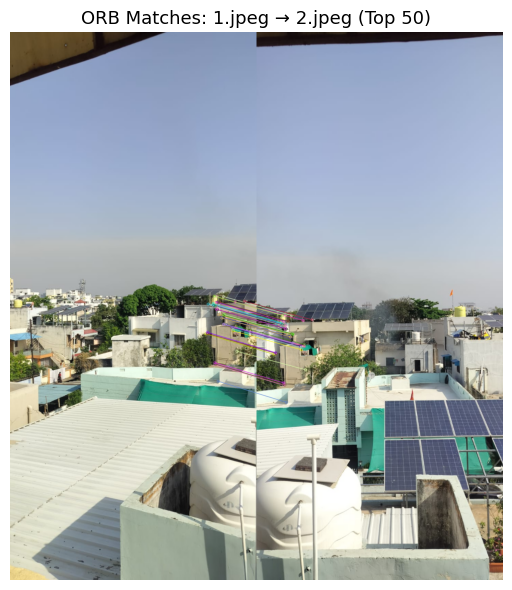

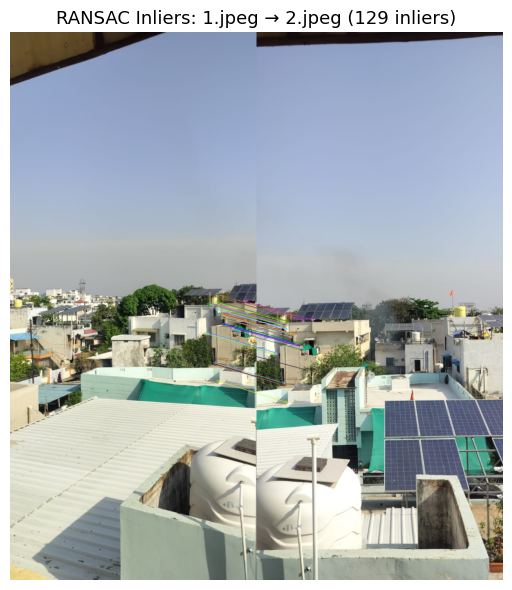

In [9]:
if len(frames) >= 2:
    kp1, kp2, md = detect_and_match_orb(frames[0], frames[1])
    Hd, mkd = compute_homography_ransac(kp1, kp2, md)
    print(f'Matches: {len(md)}  |  Inliers: {int(mkd.sum()) if mkd is not None else 0}')
    vis = cv2.drawMatches(frames[0], kp1, frames[1], kp2, md[:50], None,
                          flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    show_image(vis, f'ORB Matches: {PHOTO_ORDER[0]} → {PHOTO_ORDER[1]} (Top 50)', figsize=(18,6))

    if mkd is not None:
        inliers = [m for m, k in zip(md, mkd.ravel()) if k]
        vis2 = cv2.drawMatches(frames[0], kp1, frames[1], kp2, inliers[:50], None,
                               flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
        show_image(vis2, f'RANSAC Inliers: {PHOTO_ORDER[0]} → {PHOTO_ORDER[1]} ({len(inliers)} inliers)', figsize=(18,6))

## Step 7: Stitch All Photos into Panorama

Stitching 4 photos...

  [1/3] 1.jpeg → 2.jpeg... OK  inliers=129
  [2/3] 2.jpeg → 3.jpeg... OK  inliers=123
  [3/3] 3.jpeg → 4.jpeg... OK  inliers=16

Skipped: 0/3
Canvas: 5897x4912  |  Est. RAM: ~0.46 GB
  Blended photo 1/4: 1.jpeg
  Blended photo 2/4: 2.jpeg
  Blended photo 3/4: 3.jpeg
  Blended photo 4/4: 4.jpeg

✅ Done!  Final size: 5897x4912 px


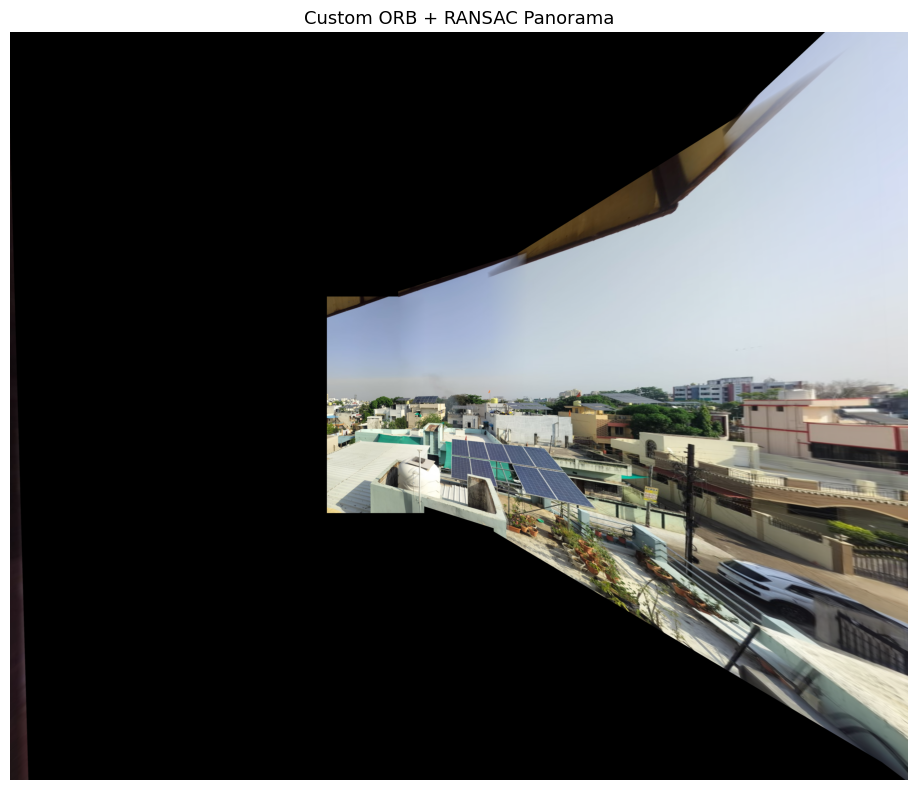

In [10]:
print(f'Stitching {len(frames)} photos...\n')

# Step A — Chain homographies ─────────────────────────────────────────────────
H_chain = [np.eye(3, dtype=np.float64)]
skipped = 0
for i in range(1, len(frames)):
    print(f'  [{i}/{len(frames)-1}] {PHOTO_ORDER[i-1]} → {PHOTO_ORDER[i]}...', end=' ')
    kp1, kp2, matches = detect_and_match_orb(frames[i-1], frames[i])
    H_rel, mask = compute_homography_ransac(kp1, kp2, matches)
    del kp1, kp2, matches; gc.collect()
    if H_rel is None:
        print('SKIP — not enough matches')
        H_chain.append(H_chain[-1].copy()); skipped += 1; continue
    H_chain.append(H_chain[-1] @ np.linalg.inv(H_rel))
    print(f'OK  inliers={int(mask.sum()) if mask is not None else 0}')

print(f'\nSkipped: {skipped}/{len(frames)-1}')

# Step B — Compute global canvas ──────────────────────────────────────────────
all_corners = []
for i, frm in enumerate(frames):
    h, w = frm.shape[:2]
    c = np.float32([[0,0],[0,h],[w,h],[w,0]]).reshape(-1,1,2)
    all_corners.append(cv2.perspectiveTransform(c, H_chain[i]))
all_corners = np.concatenate(all_corners, axis=0)
[xmin,ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
[xmax,ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)
xmin,ymin = max(xmin,-10000), max(ymin,-10000)
xmax,ymax = min(xmax, 10000), min(ymax, 10000)
canvas_w, canvas_h = xmax-xmin, ymax-ymin
tx, ty = -xmin, -ymin
T = np.array([[1,0,tx],[0,1,ty],[0,0,1]], dtype=np.float64)
ram_gb = canvas_w * canvas_h * (3+1) * 4 / 1e9
print(f'Canvas: {canvas_w}x{canvas_h}  |  Est. RAM: ~{ram_gb:.2f} GB')
if ram_gb > 2.5:
    raise MemoryError(f'Canvas too large ({ram_gb:.1f} GB). Reduce RESIZE_WIDTH in Step 3.')

# Step C — Distance-weighted blend ────────────────────────────────────────────
acc_color  = np.zeros((canvas_h, canvas_w, 3), dtype=np.float32)
acc_weight = np.zeros((canvas_h, canvas_w),    dtype=np.float32)

for i, frm in enumerate(frames):
    h, w = frm.shape[:2]
    H_abs = T @ H_chain[i]
    warped = cv2.warpPerspective(frm, H_abs, (canvas_w, canvas_h),
                                 flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)
    fmask  = np.ones((h, w), dtype=np.uint8) * 255
    wmask  = cv2.warpPerspective(fmask, H_abs, (canvas_w, canvas_h),
                                 flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT)
    dist   = cv2.distanceTransform(wmask, cv2.DIST_L2, 5).astype(np.float32)
    acc_color  += warped.astype(np.float32) * dist[:,:,np.newaxis]
    acc_weight += dist
    del warped, wmask, dist, fmask; gc.collect()
    print(f'  Blended photo {i+1}/{len(frames)}: {PHOTO_ORDER[i]}')

# Step D — Normalize ──────────────────────────────────────────────────────────
acc_weight = np.maximum(acc_weight, 1e-6)
pano_uint8 = np.clip(acc_color / acc_weight[:,:,np.newaxis], 0, 255).astype(np.uint8)
del acc_color, acc_weight; gc.collect()

# Step E — Auto-crop black borders ────────────────────────────────────────────
gray_p = cv2.cvtColor(pano_uint8, cv2.COLOR_BGR2GRAY)
_, thr  = cv2.threshold(gray_p, 1, 255, cv2.THRESH_BINARY)
coords  = cv2.findNonZero(thr)
if coords is not None:
    xr, yr, wr, hr = cv2.boundingRect(coords)
    pano_uint8 = pano_uint8[yr:yr+hr, xr:xr+wr]

panorama = pano_uint8
print(f'\n✅ Done!  Final size: {panorama.shape[1]}x{panorama.shape[0]} px')
show_image(panorama, 'Custom ORB + RANSAC Panorama', figsize=(22,8))

## Step 9: OpenCV Stitcher (Comparison)

In [12]:
print('Running OpenCV Built-in Stitcher on all photos...')
stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)
status, pano_cv = stitcher.stitch(frames)
if status == cv2.Stitcher_OK:
    print(f'Success! {pano_cv.shape[1]}x{pano_cv.shape[0]}')
    show_image(pano_cv, 'OpenCV Built-in Stitcher', figsize=(22,8))
else:
    err = {cv2.Stitcher_ERR_NEED_MORE_IMGS: 'Need more images',
           cv2.Stitcher_ERR_HOMOGRAPHY_EST_FAIL: 'Homography failed',
           cv2.Stitcher_ERR_CAMERA_PARAMS_ADJUST_FAIL: 'Camera params failed'}
    print(f'Failed: {err.get(status, f"Code {status}")}')
    pano_cv = None

Running OpenCV Built-in Stitcher on all photos...
Failed: Need more images


## Step 10: Side-by-Side Comparison

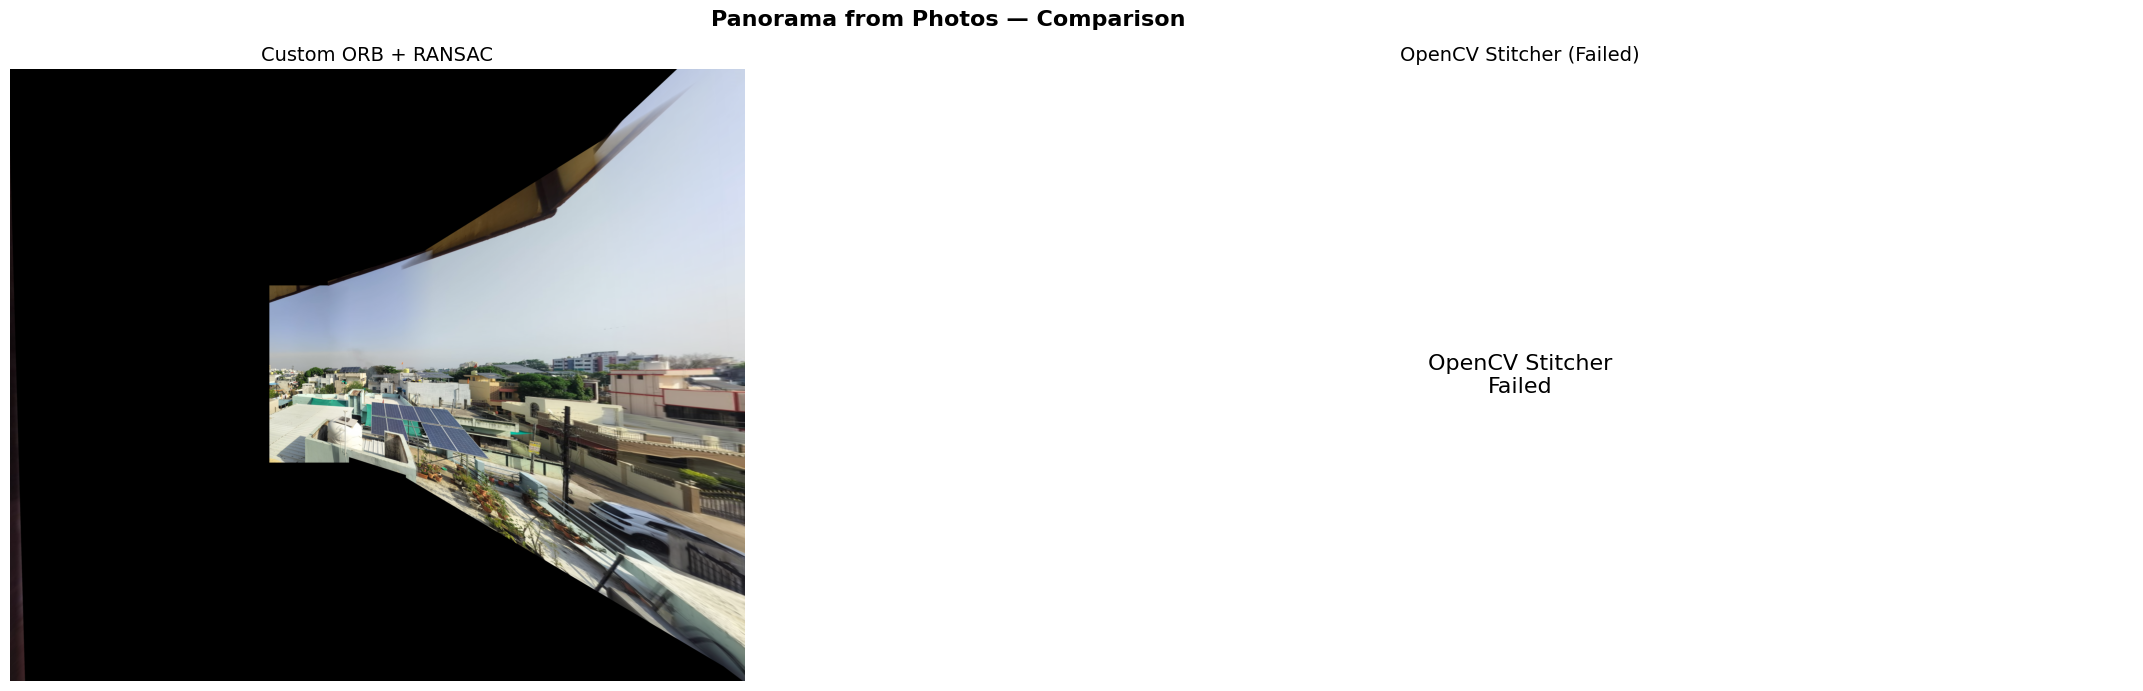

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(24,7))
axes[0].imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
axes[0].set_title('Custom ORB + RANSAC', fontsize=14); axes[0].axis('off')
if pano_cv is not None:
    axes[1].imshow(cv2.cvtColor(pano_cv, cv2.COLOR_BGR2RGB))
    axes[1].set_title('OpenCV Built-in Stitcher', fontsize=14)
else:
    axes[1].text(0.5, 0.5, 'OpenCV Stitcher\nFailed', ha='center', va='center', fontsize=16)
    axes[1].set_title('OpenCV Stitcher (Failed)', fontsize=14)
axes[1].axis('off')
plt.suptitle('Panorama from Photos — Comparison', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

## Step 11: Save & Download

In [14]:
cv2.imwrite('panorama_custom.jpg', panorama)
cv2.imwrite('panorama_blended.jpg', blended_pano)
print('Saved: panorama_custom.jpg, panorama_blended.jpg')
if pano_cv is not None:
    cv2.imwrite('panorama_opencv.jpg', pano_cv)
    print('Saved: panorama_opencv.jpg')
files.download('panorama_custom.jpg')
files.download('panorama_blended.jpg')
if pano_cv is not None:
    files.download('panorama_opencv.jpg')

Saved: panorama_custom.jpg, panorama_blended.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>